# Phase 1 - Markdown



## Loading Dataset


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("Dengue diseases dataset.csv")

Data Preparation Complete.
Final shape: (989, 9)


**Purpose of Each Line of the Code**

This section initializes the required Python libraries used for data processing, machine learning, and evaluation. After loading the libraries, the dengue dataset is imported into the notebook for further analysis

*   import pandas as pd - It is used to help us work with our data and allows us to easily read, organize, and analyze data.
*   import numpy as np - It is a library used for mathematical calculations and arrays of numbers. It helps perform fast numerical operations needed in data analysis.
*   from sklearn.preprocessing import MinMaxScaler - It is a tool used to normalize or scale numbers, adjusts numerical values so it will range to 0 to 1, which helps machine learning models perform better.
*   from sklearn.model_selection import train_test_split - It is used to divide the dataset into two parts which is the Training data, which is used to teach the model and Testing data, which is used to check how well the model learned.
*   from sklearn.linear_model import LogisticRegression - It is a machine learning model used for classification.
*   from sklearn.metrics import accuracy_score, confusion_matrix, classification_report - These are evaluation tools used to measure how well the model performs such as Accuracy Score, which shows how many predictions were correct, Confusion Matrix, which shows correct and incorrect predictions in detail, and Classification Report, which provides detailed performance metrics like precision, recall, and F1-score
*   df = pd.read_csv("Dengue diseases dataset.csv") - It loads the file dengue and stored it in the varaiable df, which also allows us to start analyzing the data using the data.

**Input**

The input for this is the dataset "Dengue diseases dataset.csv." This dataset contains several health-related features of patients that may help identify whether a person has dengue or not. The data includes different medical indicators that are commonly associated with dengue infection.

**Output**

The output of this is a Pandas DataFrame called df, which contains the dataset that was loaded from the data file. The data is organized into rows and columns, making it easier to understand and work. Each row represents the information of one patient, while each column represents a medical feature or health-related detail included in the dataset.

## Data Cleaning and Processing

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Remove rows with missing target
df = df.dropna(subset=["Final Output"])

# Fill missing numeric values
df["WBC Count"] = df["WBC Count"].fillna(df["WBC Count"].median())
df["Platelet Count"] = df["Platelet Count"].fillna(df["Platelet Count"].median())
df["PDW"] = df["PDW"].fillna(df["PDW"].median())

# Clean Sex column
df["Sex"] = df["Sex"].astype(str).str.strip().str.capitalize()

# Encode Sex with Child included
df["Sex"] = df["Sex"].map({
    "Female": 0,
    "Male": 1,
    "Child": 2
})

# Fill any remaining missing Sex values with mode
df["Sex"] = df["Sex"].fillna(df["Sex"].mode()[0])

# Scale numeric features
scaler = MinMaxScaler()

numeric_cols = [
    "Age",
    "Haemoglobin",
    "WBC Count",
    "Differential Count",
    "RBC PANEL",
    "Platelet Count",
    "PDW"
]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Make sure target is integer
df["Final Output"] = df["Final Output"].astype(int)

# Save cleaned dataset
df.to_csv("cleaned_dengue_dataset.csv", index=False)

print("Data Preparation Complete.")
print("Final shape:", df.shape)

**Purpose of Each Line of Code**

This section prepares the dataset by cleaning column names, handling missing values, encoding categorical variables, and normalizing numerical features.

*   df.columns = df.columns.str.strip() - It removes any extra spaces in the column names of the dataset. Because, some columns names have spaces before or after the text, which can cause errors when referencing them in the code.
*   df = df.dropna(subset=["Final Output"]) - It removes all rows where Final Ouput value is missing, since every row must have a valid value for the model to learn properly.
*   df["WBC Count"].fillna(df["WBC Count"].median()) - It replaces any missing values in the WBC Count column with the median value. Also, using the median helps maintain the dataset without removing rows and avoids extreme values affecting the data.
*   df["Platelet Count"].fillna(df["Platelet Count"].median()) -
It also fills in missing values but in the Platelet Count column using its median value. This also helps keep the dataset complete and balanced.
*   df["PDW"].fillna(df["PDW"].median()) - It handles missing values in the PDW column by replacing them with the median of the PDW values in the dataset.
*   MinMaxScaler()- It is used to normalize the numerical values in the dataset so the value will fall within a range of 0 to 1. Scaling the data helps improve the performance and stability of the machine learning model.
*   df.to_csv("cleaned_dengue_dataset.csv") - This line saves the cleaned and processed dataset into a new CSV file called cleaned_dengue_dataset.csv.

**Input**

The input for this is the raw dengue dataset. This dataset contains several health-related features that are used during the preprocessing stage to prepare the data for machine learning. Some of the important columns included in the preprocessing process are Age, Sex, Haemoglobin, WBC Count, Differential Count, RBC Panel, Platelet Count, PDW, and Final Output. These features represent different medical measurements and patient information that may help in identifying patterns related to dengue infection. During preprocessing, these columns are checked, cleaned, and prepared so they can be properly used in the machine learning model.

**Output**

The output of this is a cleaned and normalized dataset saved as cleaned_dengue_dataset.csv. After preprocessing, the dataset is properly prepared for machine learning analysis. The data no longer contains missing values from all the columns. Categorical variables, such as Sex, have been converted into numerical values so that they can be processed by the machine learning model. In addition, the numerical features have been normalized, which means their values are scaled between 0 and 1 to improve the model's performance and stability during training.

## Training and Evaluation

In [ ]:
# Features and target
X = df["Platelet Count"]
y = df["Final Output"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

**Purpose of Each Line of Code**
This section trains a Logistic Regression model using the prepared dataset and evaluates its predictive performance.

*   X = df["Platelet Count"] - This is the predictor.It is a medical data that will be used to predict the dengue.
*   y = df["Final Output"] - This is the target variable called y. It is a result which indicated if the patient have dengue or not.
*   train_test_split() - It splits the dataset into training and testing subsets. 80% for training to and 20% to test for unseen data.
*   model = LogisticRegression() - It is a machine learning model used for classification.
*   model.fit(X_train, y_train) - It trains the model using the training dataset. The model learns patterns from the medical features to understand how they relate to the dengue classification.
*   y_pred = model.predict(X_test) - After training, the model is used to make predictions on the test dataset. The predicted results are stored in y_pred.
*   accuracy_score() - It calculates the accuracy of the model, which shows the percentage of predictions that were correct.
*   confusion_matrix() - It displays a table that compares the predicted results with the actual results. It helps show how many predictions were correct and how many were incorrect.
*   classification_report() - It provides a detailed evaluation of the model's performance, including metrics such as precision, recall, and F1-score, which help measure how well the model classifies dengue cases.

**Input**

The input for this includes the cleaned dataset named cleaned_dengue_dataset.csv, which was prepared during the preprocessing stage.The inputs are divided into two parts, the predictor variables, which consist of the different medical measurements such as blood test results and patient details, and the target variable, called Final Output. The predictor variables are used by the model to learn patterns in the data, while the Final Output serves as the label that indicates the classification result for dengue.

**Output**

The output of this includes several evaluation metrics that are displayed in the notebook after the model makes predictions. These outputs include the Accuracy Score, Confusion Matrix, and Classification Report. The Accuracy Score shows the percentage of correct predictions made by the model. The Confusion Matrix provides a summary of correct and incorrect predictions, allowing us to see how the model classified the dengue cases. Meanwhile, the Classification Report gives more detailed performance metrics such as precision, recall, and F1-score. Together, these results help determine how well the logistic regression model performs in predicting dengue cases based on the medical features in the dataset.

## Visualization

In [ ]:
    # Generate smooth x values
    x_array = np.linspace(X["Platelet Count"].min(), X["Platelet Count"].max(), 300)

    # Convert to DataFrame with correct feature name
    x_values = pd.DataFrame({
        "Platelet Count": x_array
    })

    # Predict probabilities
    probs = model.predict_proba(x_values)[:, 1]

    # Plot sigmoid curve
    plt.figure(figsize=(8, 6))
    plt.scatter(X["Platelet Count"], y, color="red", alpha=0.4, label="Actual Data")
    plt.plot(x_array, probs, color="blue", linewidth=3, label="Sigmoid Curve")
    plt.xlabel("Platelet Count")
    plt.ylabel("Probability of Dengue")
    plt.title(f"Sigmoid Curve (C = {c})")
    plt.legend()
    plt.show()

**Purpose of Each Line of Code**

This section visualizes the logistic regression model using a sigmoid curve based on the predictor variable

*   np.linspace() - This function generates a set of evenly spaced platelet count values within a specified range. These values are used to help create a smooth curve for the graph
*   model.predict_proba() - This function calculates the probability that a patient has dengue for each platelet count value generated earlier. It helps show how the likelihood of dengue changes as platelet count changes.
*   plt.scatter() - This function plots the actual data points from the dataset on the graph. Each point represents a real patient record.
*   plt.plot() - This function draws the S-shaped curve that represents the predicted probability of dengue based on the model.
*   plt.show() - This displays the final graph, allowing us to visually see the relationship between platelet count and the predicted probability of dengue.

**Input**

The input for this includes the Platelet Count feature values from the dataset, the target classification labels that indicate whether a patient has dengue or not, and the trained logistic regression model developed in the previous stage. The platelet count values are used as the main feature for visualization, while the target labels represent the actual classification results in the dataset. The trained logistic regression model is then used to calculate the predicted probability of dengue, which will later be visualized in the graph.

**Output**

The output of this is a sigmoid curve visualization that shows the relationship between Platelet Count and the probability of dengue classification. The graph includes red data points, which represent the actual observations from the dataset, and a blue sigmoid curve, which represents the predicted probabilities generated by the logistic regression model. This visualization helps illustrate how the logistic regression model separates dengue and non-dengue cases based on the platelet count values, making it easier to understand how the model makes its predictions.

## Cross Validation Markdown


In [ ]:
# Implement Stratified K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

# Print results
print("=" * 60)
print("Cross-Validation")

for i, score in enumerate(scores, start=1):
    print(f"Fold {i} Accuracy: {score:.2%}")

print("Mean Accuracy: {:.2%}".format(scores.mean()))
print("Overall Mean Accuracy: {:.2%}".format(scores.std()))

# Visualize line chart of accuracies
plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(scores)+1),
    scores,
    marker="o",
    linestyle="--",
    color="blue",
    label="Fold Accuracy"
)

plt.axhline(
    y=scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean Accuracy: {scores.mean():.4f}"
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(scores)+1))
plt.ylim(0.6, 1.05)
plt.legend()
plt.grid(True)

plt.show()

This section evaluates the stability and reliability of the logistic regression model using 5-Fold Stratified Cross-Validation.

Instead of using a single train-test split, the dataset is divided into five subsets. The model is trained on four folds and tested on the remaining fold. This process repeats five times so that every fold is used once as testing data.


*  KFold(n_splits=5, shuffle=True, random_state=42) - This function splits the dataset into five groups for cross-validation. The shuffle=True option mixes the data before splitting, and random_state=42 ensures that the results can be reproduced.
*   cross_val_score(model, X, y, cv=kf, scoring="accuracy") - It trains and tests the logistic regression model using the folds created earlier. The model is trained multiple times and evaluated on different parts of the dataset. It returns the accuracy score for each fold.
*   scores.mean() - It calculates the average accuracy of the model across all five folds. It gives an overall idea of how well the model performs.
*   scores.std() - It calculates the standard deviation of the accuracy scores. It shows how consistent the model performance is across the folds. A smaller value means the model is more stable.

**Input**

The input for this is the cleaned dataset. From this dataset, the variables used include the predictor variable, Platelet Count, which serves as the input feature for the model, and the target variable, Final Output, which represents the dengue classification result. During cross-validation, the dataset is divided into five folds, allowing the model to be trained and tested multiple times using different portions of the data. This helps provide a more reliable evaluation of the model's performance.

**Output**

The output of this stage includes several evaluation results from the cross-validation process. These results show the accuracy score for each fold, the mean average accuracy across all folds, and the standard deviation of the accuracy values. Also, a visualization of the fold accuracies is generated to make the results easier to understand.

# Phase 2

## Pipeline

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("Dengue diseases dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Remove rows with missing target
df = df.dropna(subset=["Final Output"])

# Fill missing numeric values
df["WBC Count"] = df["WBC Count"].fillna(df["WBC Count"].median())
df["Platelet Count"] = df["Platelet Count"].fillna(df["Platelet Count"].median())
df["PDW"] = df["PDW"].fillna(df["PDW"].median())

# Clean Sex column
df["Sex"] = df["Sex"].astype(str).str.strip().str.capitalize()

# Encode Sex with Child included
df["Sex"] = df["Sex"].map({
    "Female": 0,
    "Male": 1,
    "Child": 2
})

# Fill any remaining missing Sex values with mode
df["Sex"] = df["Sex"].fillna(df["Sex"].mode()[0])

# Scale numeric features
scaler = MinMaxScaler()

numeric_cols = [
    "Age",
    "Haemoglobin",
    "WBC Count",
    "Differential Count",
    "RBC PANEL",
    "Platelet Count",
    "PDW"
]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Make sure target is integer
df["Final Output"] = df["Final Output"].astype(int)

# Save cleaned dataset
df.to_csv("cleaned_dengue_dataset.csv", index=False)

print("Data Preparation Complete.")
print("Final shape:", df.shape)


Data Preparation Complete.
Final shape: (989, 9)


## Experiment 1 - Hyperparameter Tuning Experiment

Experiment 1
C Value: 0.001
Accuracy: 67.68%
Confusion Matrix:
[[  0  64]
 [  0 134]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        64
           1       0.68      1.00      0.81       134

    accuracy                           0.68       198
   macro avg       0.34      0.50      0.40       198
weighted avg       0.46      0.68      0.55       198



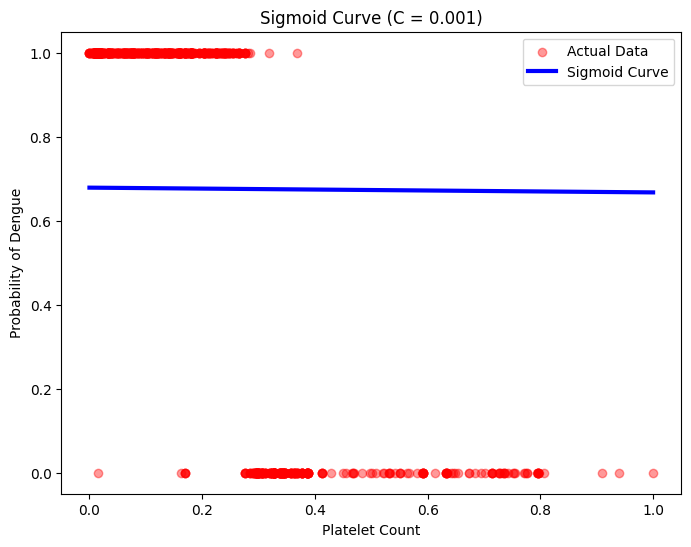

Experiment 1
C Value: 1.0
Accuracy: 96.97%
Confusion Matrix:
[[ 59   5]
 [  1 133]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        64
           1       0.96      0.99      0.98       134

    accuracy                           0.97       198
   macro avg       0.97      0.96      0.96       198
weighted avg       0.97      0.97      0.97       198



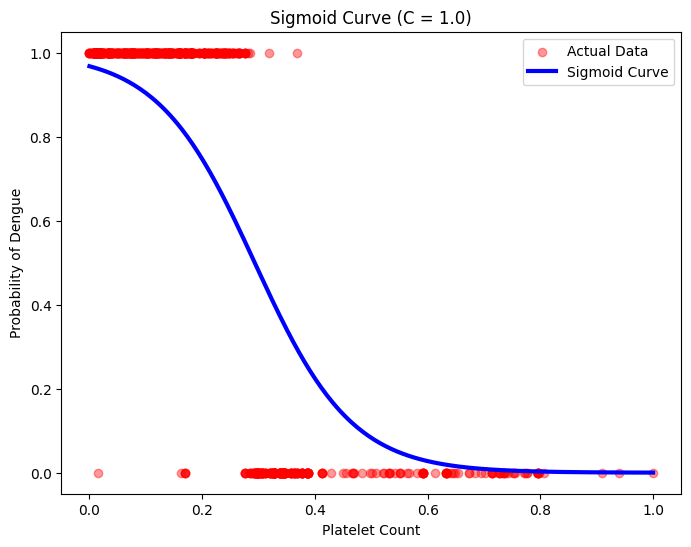

Experiment 1
C Value: 1000
Accuracy: 98.48%
Confusion Matrix:
[[ 63   1]
 [  2 132]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98        64
           1       0.99      0.99      0.99       134

    accuracy                           0.98       198
   macro avg       0.98      0.98      0.98       198
weighted avg       0.98      0.98      0.98       198



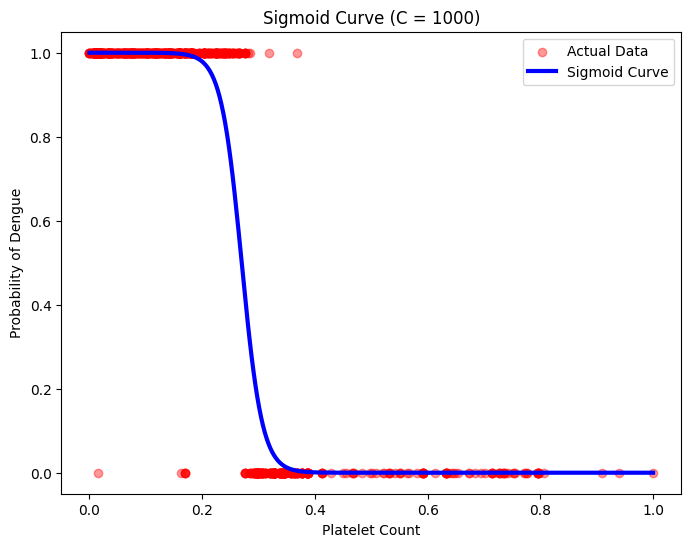

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load cleaned dataset
df = pd.read_csv("cleaned_dengue_dataset.csv")

# USE ONLY ONE PREDICTOR
X = df[["Platelet Count"]]
y = df["Final Output"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Test different C values
c_values = [0.001, 1.0, 1000]

for c in c_values:
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("=" * 60)
    print("Experiment 1")
    print("C Value:", c)
    print("Accuracy: {:.2%}".format(accuracy_score(y_test, y_pred)))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Generate smooth x values
    x_array = np.linspace(X["Platelet Count"].min(), X["Platelet Count"].max(), 300)

    # Convert to DataFrame with correct feature name
    x_values = pd.DataFrame({
        "Platelet Count": x_array
    })

    # Predict probabilities
    probs = model.predict_proba(x_values)[:, 1]

    # Plot sigmoid curve
    plt.figure(figsize=(8, 6))
    plt.scatter(X["Platelet Count"], y, color="red", alpha=0.4, label="Actual Data")
    plt.plot(x_array, probs, color="blue", linewidth=3, label="Sigmoid Curve")
    plt.xlabel("Platelet Count")
    plt.ylabel("Probability of Dengue")
    plt.title(f"Sigmoid Curve (C = {c})")
    plt.legend()
    plt.show()


## Experiment 2 - Feature Engineering and Selection

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load cleaned dataset
df = pd.read_csv("cleaned_dengue_dataset.csv")

# Define different feature combinations
feature_sets = {

    "Model A (Single Feature)": ["Age"],

    "Model B (Core Medical Features)": [
        "Platelet Count",
        "WBC Count",
        "PDW"
    ],

    "Model C (All Features)": [
        "Age",
        "Sex",
        "Haemoglobin",
        "WBC Count",
        "Differential Count",
        "RBC PANEL",
        "Platelet Count",
        "PDW"
    ]
}

# Target variable
y = df["Final Output"]

# Run experiment
for model_name, features in feature_sets.items():

    X = df[features]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(C=1.0, max_iter=1000)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("="*60)
    print(model_name)
    print("Features Used:", features)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    print("Train Accuracy:", model.score(X_train, y_train))
    print("Test Accuracy:", model.score(X_test, y_test))

    from sklearn.model_selection import cross_val_score

    scores = cross_val_score(
        LogisticRegression(max_iter=1000),
        X,
        y,
        cv=5
    )

    print("Cross Validation Accuracy:", scores.mean())

Model A (Single Feature)
Features Used: ['Age']
Accuracy: 0.6767676767676768
Confusion Matrix:
[[  0  64]
 [  0 134]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        64
           1       0.68      1.00      0.81       134

    accuracy                           0.68       198
   macro avg       0.34      0.50      0.40       198
weighted avg       0.46      0.68      0.55       198

Train Accuracy: 0.6814159292035398
Test Accuracy: 0.6767676767676768
Model B (Core Medical Features)
Features Used: ['Platelet Count', 'WBC Count', 'PDW']
Accuracy: 0.9848484848484849
Confusion Matrix:
[[ 61   3]
 [  0 134]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        64
           1       0.98      1.00      0.99       134

    accuracy                           0.98       198
   macro avg       0.99      0.98      0.98       198
weighted avg

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model C (All Features)
Features Used: ['Age', 'Sex', 'Haemoglobin', 'WBC Count', 'Differential Count', 'RBC PANEL', 'Platelet Count', 'PDW']
Accuracy: 0.9848484848484849
Confusion Matrix:
[[ 61   3]
 [  0 134]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        64
           1       0.98      1.00      0.99       134

    accuracy                           0.98       198
   macro avg       0.99      0.98      0.98       198
weighted avg       0.99      0.98      0.98       198

Train Accuracy: 0.988621997471555
Test Accuracy: 0.9848484848484849
Cross Validation Accuracy: 0.9878736604624929


## Experiment 3 - Decision Threshold Adjustment


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load cleaned dataset
df = pd.read_csv("cleaned_dengue_dataset.csv")

# Features and target
X = df[["WBC Count"]]
y = df["Final Output"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train logistic regression model
model = LogisticRegression(C=1.0, max_iter=1000)
model.fit(X_train, y_train)

# Get predicted probabilities for class 1
y_probs = model.predict_proba(X_test)[:, 1]

# Test different thresholds
thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)

    print("=" * 60)
    print("Experiment 3 - Threshold =", t)
    print("Accuracy: {:.2%}".format(accuracy_score(y_test, y_pred)))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

Experiment 3 - Threshold = 0.3
Accuracy: 93.94%
Confusion Matrix:
[[ 52  12]
 [  0 134]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.81      0.90        64
           1       0.92      1.00      0.96       134

    accuracy                           0.94       198
   macro avg       0.96      0.91      0.93       198
weighted avg       0.94      0.94      0.94       198

Experiment 3 - Threshold = 0.5
Accuracy: 97.47%
Confusion Matrix:
[[ 59   5]
 [  0 134]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        64
           1       0.96      1.00      0.98       134

    accuracy                           0.97       198
   macro avg       0.98      0.96      0.97       198
weighted avg       0.98      0.97      0.97       198

Experiment 3 - Threshold = 0.7
Accuracy: 99.49%
Confusion Matrix:
[[ 63   1]
 [  0 134]]
Classification Report:
          

# Cross Validation

Cross-Validation
Fold 1 Accuracy: 97.47%
Fold 2 Accuracy: 97.98%
Fold 3 Accuracy: 96.97%
Fold 4 Accuracy: 97.98%
Fold 5 Accuracy: 96.95%
Mean Accuracy: 97.47%
Overall Mean Accuracy: 0.46%


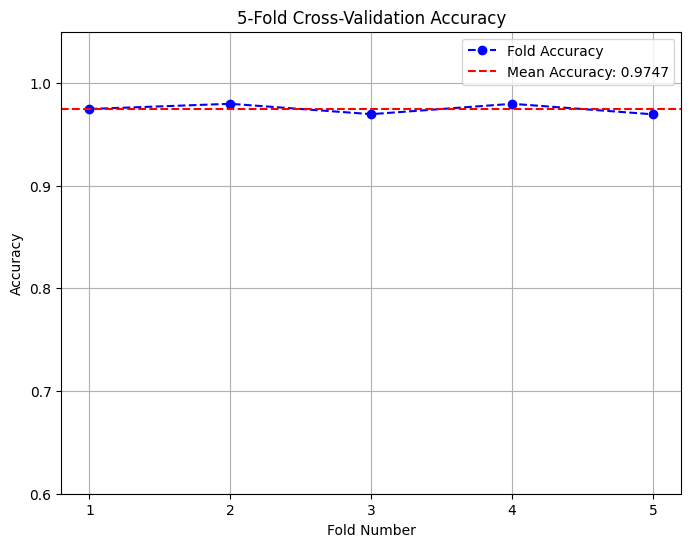

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Load cleaned dataset
df = pd.read_csv("cleaned_dengue_dataset.csv")

# Feature and target variable
X = df[["WBC Count"]]
y = df["Final Output"]

# Define Logistic Regression model (default parameters)
model = LogisticRegression(max_iter=1000)

# Implement K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

# Print results
print("=" * 60)
print("Cross-Validation")

for i, score in enumerate(scores, start=1):
    print(f"Fold {i} Accuracy: {score:.2%}")

print("Mean Accuracy: {:.2%}".format(scores.mean()))
print("Overall Mean Accuracy: {:.2%}".format(scores.std()))

# Visualize line chart of accuracies
plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(scores)+1),
    scores,
    marker="o",
    linestyle="--",
    color="blue",
    label="Fold Accuracy"
)

plt.axhline(
    y=scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean Accuracy: {scores.mean():.4f}"
)

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(scores)+1))
plt.ylim(0.6, 1.05)
plt.legend()
plt.grid(True)

plt.show()

# BEST FEATURE SELECTION


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("cleaned_dengue_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Separate features and target
X = df.drop("Final Output", axis=1)
y = df["Final Output"]

# Encode categorical columns if needed
X = pd.get_dummies(X, drop_first=True)

# Handle missing values
X = X.fillna(X.median(numeric_only=True))

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

# Show feature importance using absolute coefficient values
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Absolute Importance": abs(model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Absolute Importance", ascending=False
)

print(feature_importance)

              Feature  Coefficient  Absolute Importance
3           WBC Count    -8.765208             8.765208
6      Platelet Count    -6.174117             6.174117
5           RBC PANEL    -1.093198             1.093198
4  Differential Count    -1.085950             1.085950
0                 Age    -1.005092             1.005092
7                 PDW    -0.740463             0.740463
1                 Sex    -0.113155             0.113155
2         Haemoglobin    -0.038401             0.038401


Model C (All Features)
Features Used: ['Age', 'Sex', 'Haemoglobin', 'WBC Count', 'Differential Count', 'RBC PANEL', 'Platelet Count', 'PDW']
Threshold Used: 0.5
Accuracy: 0.9747

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        64
           1       0.96      1.00      0.98       134

    accuracy                           0.97       198
   macro avg       0.98      0.96      0.97       198
weighted avg       0.98      0.97      0.97       198



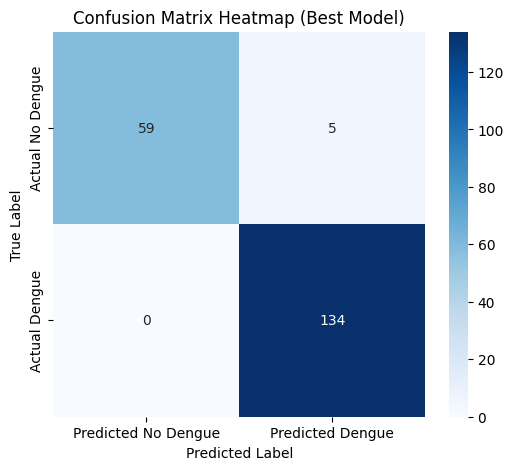


Cross-Validation Results
Fold 1 Accuracy: 97.47%
Fold 2 Accuracy: 98.48%
Fold 3 Accuracy: 98.99%
Fold 4 Accuracy: 99.49%
Fold 5 Accuracy: 99.49%
Mean Accuracy: 98.79%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# Model C (All Features)
all_features = ['Age', 'Sex', 'Haemoglobin', 'WBC Count',
                'Differential Count', 'RBC PANEL', 'Platelet Count', 'PDW']

X = df[all_features]
y = df['Final Output']

# Train Model
model_c = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model_c.fit(X_train, y_train)

# Apply Threshold = 0.5
threshold = 0.5

# Get prediction probabilities
y_prob = model_c.predict_proba(X_test)[:,1]

# Apply threshold
y_pred = (y_prob >= threshold).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("="*60)
print("Model C (All Features)")
print("Features Used:", all_features)
print(f"Threshold Used: {threshold}")
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted No Dengue', 'Predicted Dengue'],
            yticklabels=['Actual No Dengue', 'Actual Dengue'])

plt.title("Confusion Matrix Heatmap (Best Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Cross Validation
cv_scores = cross_val_score(model_c, X, y, cv=5, scoring='accuracy')

print("\nCross-Validation Results")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i} Accuracy: {score*100:.2f}%")

print(f"Mean Accuracy: {cv_scores.mean()*100:.2f}%")